7043 customers, 33 columns. Target is Churn Value (1 = churned, 0 = stayed).
Downloaded from Kaggle (yeanzc/telco-customer-churn-ibm-dataset), a public IBM sample, about 1.25 MB.
These are one-row-per-customer records, not time-series. kagglehub caches the file so re-runs get the same data.

In [1]:
import kagglehub

# Download latest version (cached locally on re-runs)
path = kagglehub.dataset_download("yeanzc/telco-customer-churn-ibm-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/ducnguyen/.cache/kagglehub/datasets/yeanzc/telco-customer-churn-ibm-dataset/versions/1


In [2]:
import pandas as pd
import os

df = pd.read_excel(os.path.join(path, "Telco_customer_churn.xlsx"))

print(df.shape)
df.head()

(7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:

df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

blanks = df["Total Charges"].isna()
print("Blank Total Charges:", blanks.sum(), "| their tenure values:", df.loc[blanks, "Tenure Months"].unique())

Blank Total Charges: 11 | their tenure values: [0]


CustomerID is for identification, should be dropped. The location fields (Lat Long, Latitude, Longitude, Zip Code, City) identify customers and are dropped before modeling.
Count, Country, and State are constant. Churn Score, Churn Reason, and CLTV are computed from the outcome (leakage), so they are dropped too.

We split off a test set now and do not look at it during EDA, so exploration cannot bias our choices. The ratio is 80/20. Stratified on the target to keep the churn ratio.

In [4]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["Churn Value"]
)

print("Train:", train_df.shape, " Test (set aside):", test_df.shape)

Train: (5634, 33)  Test (set aside): (1409, 33)


In [5]:
explore = train_df.copy()

Type, unique values, percent missing, and an example for each column.

In [6]:
summary = pd.DataFrame({
    "dtype": explore.dtypes.astype(str),
    "n_unique": explore.nunique(),
    "pct_missing": (explore.isna().mean() * 100).round(2),
    "example": [explore[c].dropna().iloc[0] if explore[c].notna().any() else None
                for c in explore.columns],
})
summary

,dtype,n_unique,pct_missing,example
CustomerID,str,5634,0.00,4950-BDEUX
Count,int64,1,0.00,1
Country,str,1,0.00,United States
State,str,1,0.00,California
City,str,1128,0.00,Apple Valley
Zip Code,int64,1650,0.00,92308
Lat Long,str,1650,0.00,"34.424926, -117.184503"
Latitude,float64,1650,0.00,34.424926
Longitude,float64,1649,0.00,-117.184503
Gender,str,2,0.00,Male


Most columns are categorical. Tenure Months, Monthly Charges, and Total Charges are numeric.
Churn Reason is mostly missing (only filled for churners). Total Charges has a few missing values (the 0-tenure customers). Count, Country, and State have one unique value.

In [7]:
explore.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,5634.0,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5626.000000,5634.000000,5634.000000,5634.000000
mean,1.0,93507.791622,36.267457,-119.785395,32.485091,64.929961,2302.604266,0.265353,58.666134,4404.100639
std,0.0,1869.181138,2.462924,2.156997,24.568744,30.138105,2279.173176,0.441560,21.548878,1182.190717
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.400000,18.850000,0.000000,5.000000,2003.000000
25%,1.0,92072.000000,34.029043,-121.804783,9.000000,35.662500,407.275000,0.000000,40.000000,3470.250000
50%,1.0,93545.000000,36.319181,-119.690560,29.000000,70.500000,1398.125000,0.000000,61.000000,4528.000000
75%,1.0,95346.000000,38.197555,-118.032222,55.000000,90.000000,3838.612500,1.000000,75.000000,5380.750000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [8]:
print("Counts:")
print(explore["Churn Value"].value_counts())
print("\nProportions:")
print(explore["Churn Value"].value_counts(normalize=True).round(3))

Counts:
Churn Value
0    4139
1    1495
Name: count, dtype: int64

Proportions:
Churn Value
0    0.735
1    0.265
Name: proportion, dtype: float64


About 26.5% churned and 73.5% stayed. Imbalanced, so we look at precision/recall/F1 (not just accuracy) and use class_weight='balanced' when modeling next week.

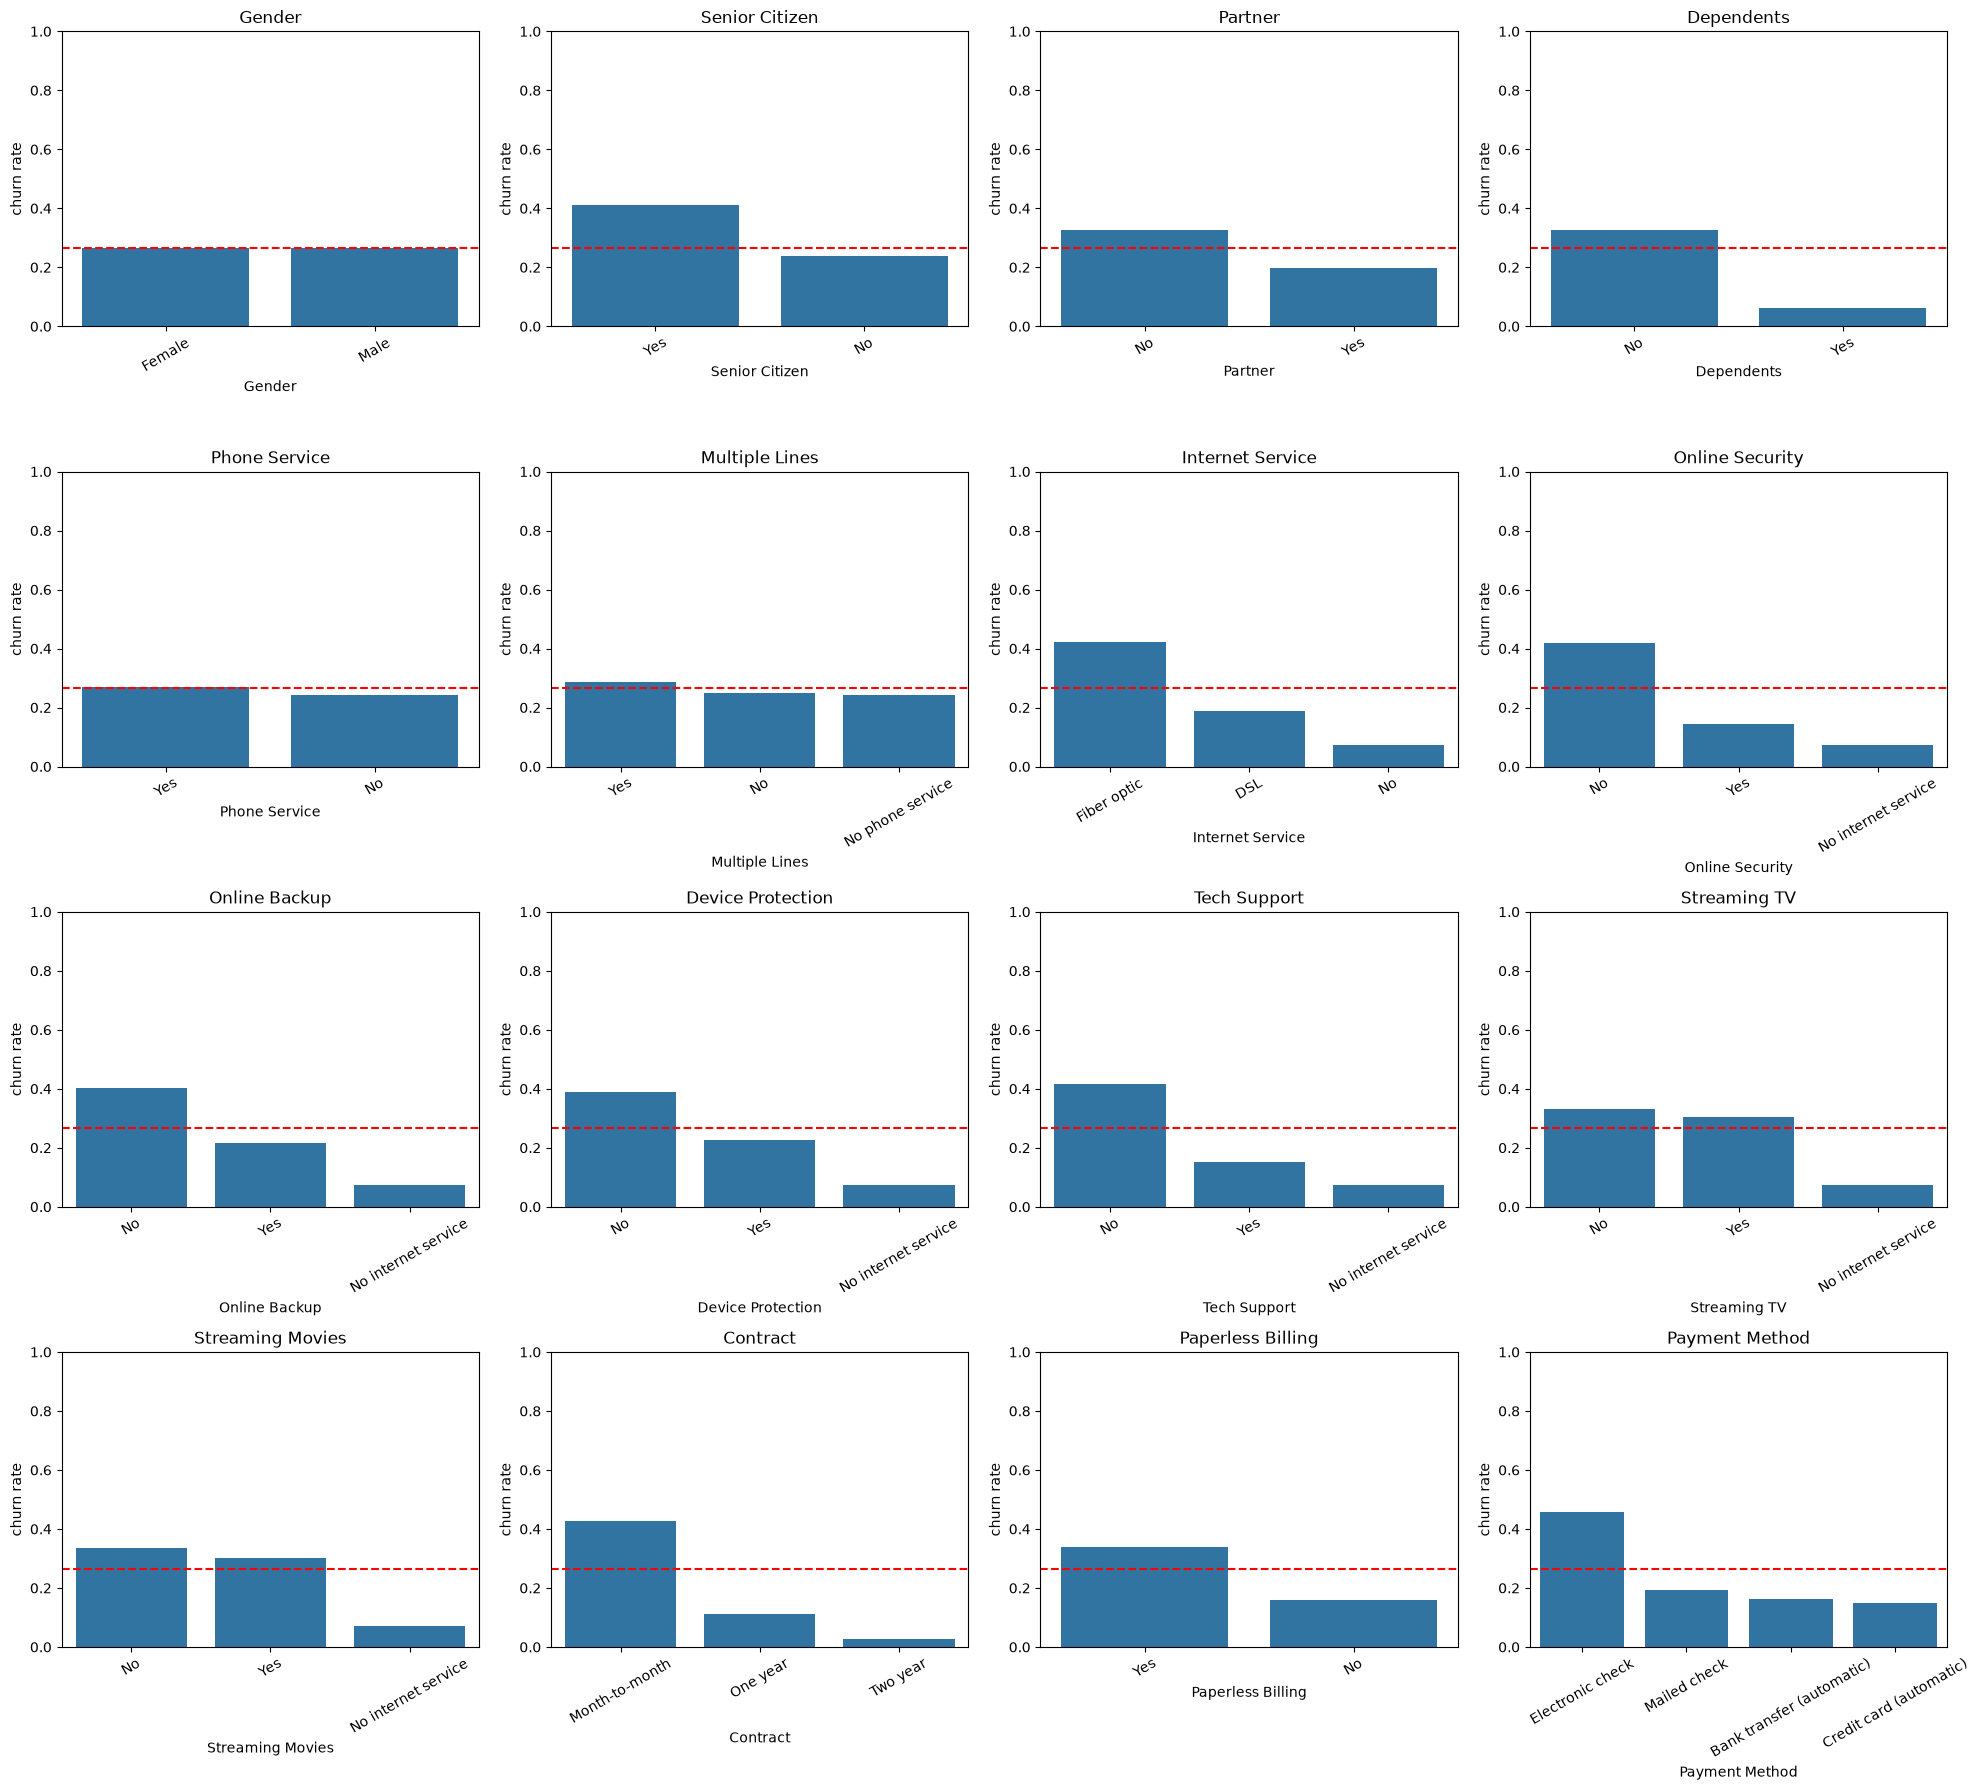

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_cols = [
    "Gender", "Senior Citizen", "Partner", "Dependents",
    "Phone Service", "Multiple Lines", "Internet Service",
    "Online Security", "Online Backup", "Device Protection",
    "Tech Support", "Streaming TV", "Streaming Movies",
    "Contract", "Paperless Billing", "Payment Method",
]

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    rate = explore.groupby(col)["Churn Value"].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, ax=ax)
    ax.axhline(explore["Churn Value"].mean(), color="red", linestyle="--")
    ax.set_title(col)
    ax.set_ylabel("churn rate")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Red dashed line is the overall churn rate.
Month-to-month contracts churn the most; one- and two-year contracts rarely churn. Fiber optic customers churn more than DSL. Customers without Online Security, Tech Support, Online Backup, or Device Protection churn more. Electronic check payers churn more than automatic payers. Gender has little effect.

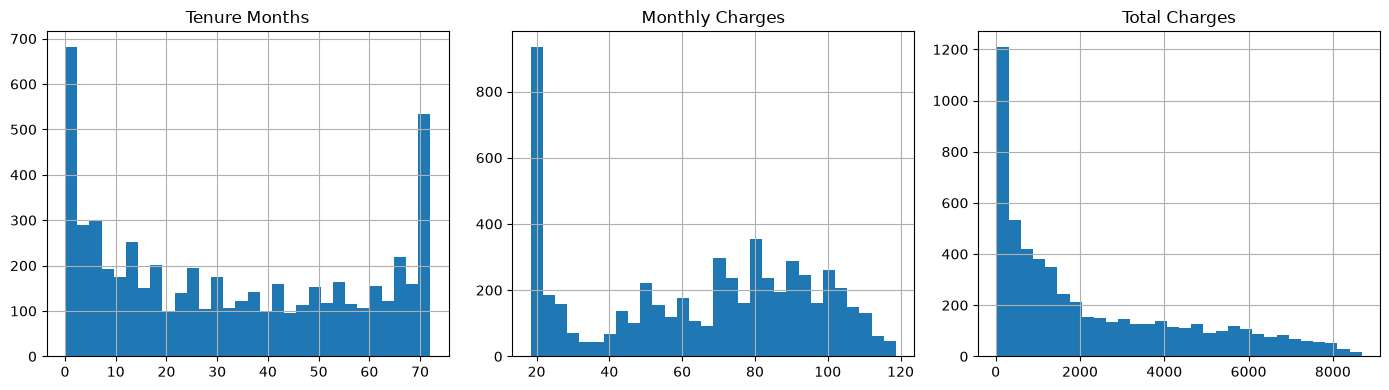

In [10]:
num_cols = ["Tenure Months", "Monthly Charges", "Total Charges"]

explore[num_cols].hist(figsize=(14, 4), bins=30, layout=(1, 3))
plt.tight_layout()
plt.show()

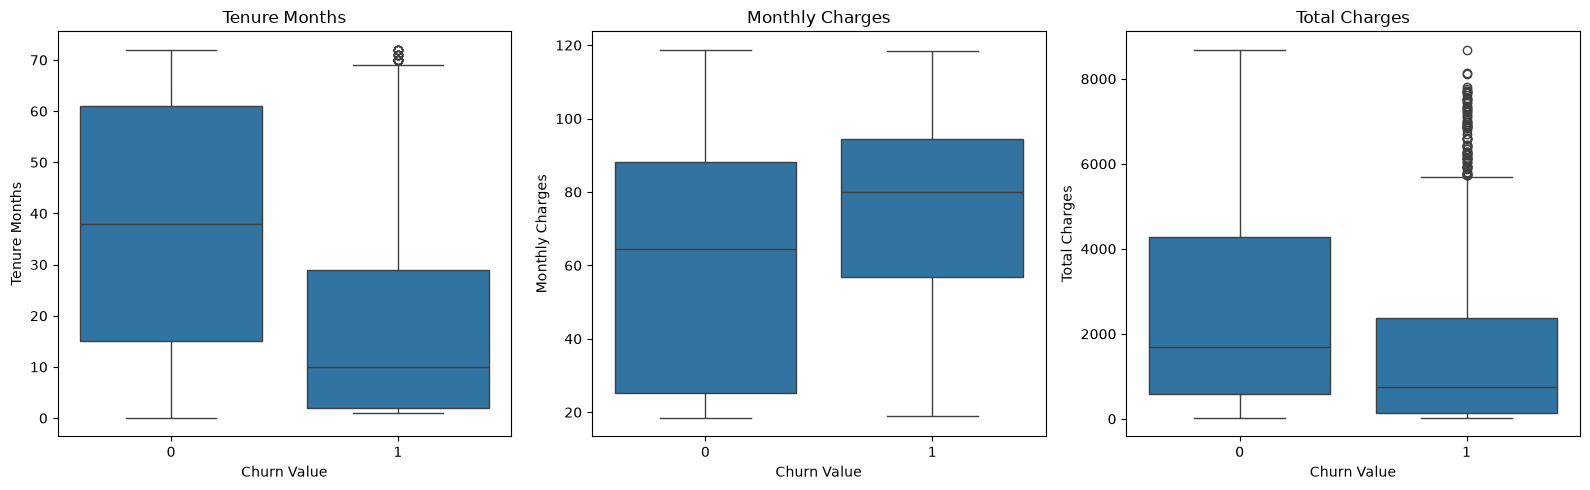

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=explore, x="Churn Value", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Tenure is bimodal and churners have lower tenure. Monthly Charges are higher for churners; Total Charges are lower (consistent with leaving early).

The numeric ranges have no impossible values, so there are no outliers to remove. Trimming real customers would only distort the churn signal.

In [12]:
explore[num_cols].agg(["min", "max"]).round(2)

,Tenure Months,Monthly Charges,Total Charges
min,0,18.40,18.85
max,72,118.75,8684.80


Correlations between the numeric attributes.

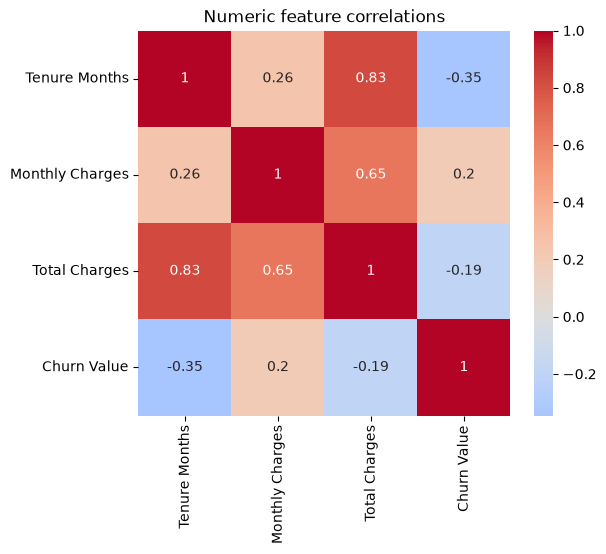

In [13]:
corr = explore[num_cols + ["Churn Value"]].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Numeric feature correlations")
plt.show()

Tenure Months and Total Charges are strongly correlated (0.83) since totals accumulate over time.
Tenure is negatively correlated with churn; Monthly Charges positively. A fuller view comes after encoding, at the end of preparation.

We write the transformations as functions and a scikit-learn pipeline so the same steps apply to the training set, the test set, and any new data.

In [14]:
# --- Column groups ---
DROP_COLS = [
    "Count", "Country", "State",                                  # constant
    "CustomerID", "City", "Zip Code", "Lat Long",                 # identifier / location
    "Latitude", "Longitude",
    "Churn Label", "Churn Score", "Churn Reason", "CLTV",         # leakage
    "Churn Value",                                                # target (handled separately)
]
BINARY_COLS  = ["Senior Citizen", "Partner", "Dependents", "Phone Service", "Paperless Billing"]
ADDON_COLS   = ["Online Security", "Online Backup", "Device Protection",
                "Tech Support", "Streaming TV", "Streaming Movies"]
NUMERIC_COLS = ["Tenure Months", "Monthly Charges", "Total Charges", "num_addon_services"]
MULTI_COLS   = ["Multiple Lines", "Internet Service", "Online Security", "Online Backup",
                "Device Protection", "Tech Support", "Streaming TV", "Streaming Movies",
                "Contract", "Payment Method", "tenure_group"]

In [15]:
def add_features(data):
    """Engineer new features. Returns a new DataFrame (original untouched)."""
    data = data.copy()
    # How many of the 6 optional add-on services the customer subscribes to
    data["num_addon_services"] = (data[ADDON_COLS] == "Yes").sum(axis=1)
    # Tenure bucketed into readable bands
    data["tenure_group"] = pd.cut(
        data["Tenure Months"], bins=[0, 12, 24, 48, 72],
        labels=["0-1yr", "1-2yr", "2-4yr", "4-6yr"], include_lowest=True,
    )
    return data


def clean_data(data):
    """Clean + binary-encode. Returns feature DataFrame (target/leakage/id removed)."""
    data = data.copy()
    # Fill the 0-tenure customers' missing Total Charges with 0
    data["Total Charges"] = pd.to_numeric(data["Total Charges"], errors="coerce").fillna(0)
    # Binary Yes/No -> 1/0
    for col in BINARY_COLS:
        data[col] = data[col].map({"Yes": 1, "No": 0})
    data["Gender"] = data["Gender"].map({"Male": 1, "Female": 0})
    return data.drop(columns=DROP_COLS)


def make_Xy(data):
    """Full raw->features pipeline for one split; also returns the target."""
    y = data["Churn Value"]
    X = clean_data(add_features(data))
    return X, y

In [16]:
X_train_raw, y_train = make_Xy(train_df)
X_test_raw,  y_test  = make_Xy(test_df)

print("X_train_raw:", X_train_raw.shape, " X_test_raw:", X_test_raw.shape)
X_train_raw.head()

X_train_raw: (5634, 21)  X_test_raw: (1409, 21)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,num_addon_services,tenure_group
4626,1,0,0,0,35,0,No phone service,DSL,No,No,...,No,Yes,Yes,Month-to-month,0,Electronic check,49.20,1701.65,3,2-4yr
4192,1,0,1,1,15,1,No,Fiber optic,Yes,No,...,No,No,No,Month-to-month,0,Mailed check,75.10,1151.55,1,1-2yr
5457,1,0,1,1,13,0,No phone service,DSL,Yes,Yes,...,Yes,No,No,Two year,0,Mailed check,40.55,590.35,3,1-2yr
4717,0,0,1,0,26,1,No,DSL,No,Yes,...,No,Yes,Yes,Two year,1,Credit card (automatic),73.50,1905.70,4,2-4yr
4673,1,0,1,1,1,1,No,DSL,No,No,...,No,No,No,Month-to-month,0,Electronic check,44.55,44.55,0,0-1yr


One-hot encode the multi-category columns, scale the numeric ones, and pass the binary columns through.
Fit on the training set only, then apply the same transform to the test set so no test information leaks in.

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_COLS),
        ("cat", OneHotEncoder(drop="first"), MULTI_COLS),
    ],
    remainder="passthrough",   # binary + Gender columns pass through unchanged
)

X_train = preprocessor.fit_transform(X_train_raw)   # fit on TRAIN only
X_test  = preprocessor.transform(X_test_raw)         # apply same transform to test

feature_names = preprocessor.get_feature_names_out()
X_train = pd.DataFrame(X_train, columns=feature_names, index=X_train_raw.index)
X_test  = pd.DataFrame(X_test,  columns=feature_names, index=X_test_raw.index)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
X_train.head()

X_train: (5634, 34)  X_test: (1409, 34)


,num__Tenure Months,num__Monthly Charges,num__Total Charges,num__num_addon_services,cat__Multiple Lines_No phone service,cat__Multiple Lines_Yes,cat__Internet Service_Fiber optic,cat__Internet Service_No,cat__Online Security_No internet service,cat__Online Security_Yes,...,cat__Payment Method_Mailed check,cat__tenure_group_1-2yr,cat__tenure_group_2-4yr,cat__tenure_group_4-6yr,remainder__Gender,remainder__Senior Citizen,remainder__Partner,remainder__Dependents,remainder__Phone Service,remainder__Paperless Billing
4626,0.102371,-0.521976,-0.262257,0.507935,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4192,-0.711743,0.337478,-0.503635,-0.570530,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
5457,-0.793155,-0.809013,-0.749883,0.507935,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4717,-0.263980,0.284384,-0.172722,1.047168,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
4673,-1.281624,-0.676279,-0.989374,-1.109762,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0


What correlates with churn once everything is numeric (training set):

In [18]:
corr_to_churn = (
    X_train.assign(**{"Churn Value": y_train.values})
      .corr(numeric_only=True)["Churn Value"]
      .drop("Churn Value")
      .sort_values(key=abs, ascending=False)
)
corr_to_churn.head(15)

num__Tenure Months                           -0.345593
cat__Internet Service_Fiber optic             0.312656
cat__Payment Method_Electronic check          0.309214
cat__Contract_Two year                       -0.302209
cat__tenure_group_4-6yr                      -0.256234
remainder__Dependents                        -0.253959
cat__Tech Support_No internet service        -0.228929
cat__Internet Service_No                     -0.228929
cat__Online Security_No internet service     -0.228929
cat__Streaming Movies_No internet service    -0.228929
cat__Online Backup_No internet service       -0.228929
cat__Device Protection_No internet service   -0.228929
cat__Streaming TV_No internet service        -0.228929
num__Monthly Charges                          0.198040
remainder__Paperless Billing                  0.197981
Name: Churn Value, dtype: float64

Two-year contracts, longer tenure, and more add-on services lower churn; month-to-month contracts, fiber optic, and electronic check raise it. Matches the EDA.

The data is now clean and numeric: missing values filled, leakage and identifier columns removed, categoricals encoded, numeric features scaled, and two features added.
X_train, X_test, y_train, y_test are ready for modeling next week, and preprocessor can transform new data the same way.